# PID loop simulator
## Run a closed loop PID simulator to allow testing different options.
## This version extracts the open loop reproduction of data from a night to use for testing.
Craig Lage 16-Apr-26

In [1]:
import numpy as np
import pickle as pkl
import pandas as pd
import galsim
from collections import deque
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import MaxNLocator
from lsst.ts.ofc import OFC, OFCData, StateEstimator, SensitivityMatrix

## The cell below sets up the simulation options

In [126]:
# Where to get the data
day_obs = 20260329
seq_start = 4
seq_end = 200

# PID loop values
# These must be arrays of length 50.
# This can probably be simplified.
# If control_vmodes = True, then the _ used values should have 12
# components.  Otherwise, if control_vmodes = False, they should have 22
indices = list(range(0, 17)) + list(range(30,35)) # This just collapses the 50 DOF down to the 22 we are using
Kp = np.zeros(50)
Kp_used = 0.3 * np.ones(22)
Kp[indices] = Kp_used
Ki = np.zeros(50)
Ki_used = 0.0 * np.ones(22)
Ki[indices] = Ki_used
Kd =np.zeros(50)

# Integral mode. Options are "Clip" and "N_images"
I_mode = "Clip"
max_images = np.zeros(22)
max_integral = 0.5 * np.ones(22)
"""
I_mode = "N_images"
max_integral = np.zeros(50)
max_images = np.zeros(50)
max_images_used = 5 * np.ones(22)
max_images[indices] = max_images_used
"""
# Correction options
N_correct = 3
discard_intermediates = False
control_vmodes = False


## The cell below gets data that allows testing.  This is how we initiate the PID simulation.

In [41]:
# Load the nightly table.
# The parquet file was created with: 
# https://github.com/lsst-sitcom/ts_aos_analysis/blob/tickets/DM-54406/notebooks/nightly_report/nightly_report_ts_version.ipynb
# THIS PARQUET TABLE MUST BE EXTRACTED AT THE SUMMIT!! USDF SOFTWARE IS BEHIND!!
parquet_file = f"/home/c/cslage/u/MTAOS/times_square_reports/nightly_aos_table_{day_obs}_summit.parquet"
table = pd.read_parquet(parquet_file)
print(f'Loaded {parquet_file}: {len(table)} rows')
print(f'Columns: {sorted(table.columns.tolist())}')

Loaded /home/c/cslage/u/MTAOS/times_square_reports/nightly_aos_table_20260329_summit.parquet: 798 rows
Columns: ['air_temp', 'airmass', 'aos_fwhm', 'azimuth', 'band', 'block', 'cam_air_temp', 'cam_m1m3_delta_t', 'day_obs', 'detector', 'dimm', 'dof_state', 'dome_delta_t', 'donut_blur_fwhm', 'elevation', 'faults', 'fwhm_zenith_500nm', 'lut_state', 'm1m3_air_temp', 'm2_air_temp', 'm2_delta_t', 'obs_end', 'obs_start', 'outside_temp', 'psf_area', 'psf_area_max', 'psf_area_min', 'psf_ellipticity_median', 'psf_ellipticity_sigma', 'psf_fwhm', 'psf_fwhm_05', 'psf_fwhm_95', 'psf_fwhm_95_05', 'psf_fwhm_max', 'psf_fwhm_min', 'psf_fwhm_sigma', 'radial_gradient', 'rotation_angle', 'seq', 'seq_num_corr', 'time', 'visit_id', 'vmodes', 'x_gradient', 'y_gradient', 'z10', 'z11', 'z12', 'z13', 'z14', 'z15', 'z16', 'z17', 'z18', 'z19', 'z22', 'z23', 'z24', 'z25', 'z26', 'z4', 'z5', 'z6', 'z7', 'z8', 'z9', 'z_gradient', 'zernikes_191', 'zernikes_195', 'zernikes_199', 'zernikes_203', 'zernikes_fwhm', 'zk_con

## Build ofc, state estimator and sensitivity matrix

In [4]:
# You will need to git clone ts_config_mttcs and replace the location with yours.
ofc_data = OFCData(
    name="lsst",
    config_dir="/home/c/cslage/WORK/ts_config_mttcs/MTAOS/ofc" 
)

ofc = OFC(
    ofc_data=ofc_data,
)

new_comp_dof_idx = dict(
    m2HexPos=np.ones(5, dtype=bool),
    camHexPos=np.ones(5, dtype=bool),
    M1M3Bend=np.ones(20, dtype=bool),
    M2Bend=np.ones(20, dtype=bool),
)

new_comp_dof_idx["M1M3Bend"][7:] = False
new_comp_dof_idx["M2Bend"][5:] = False

new_comp_dof_idx = dict(
    m2HexPos=np.ones(5, dtype=bool),
    camHexPos=np.ones(5, dtype=bool),
    M1M3Bend=np.ones(20, dtype=bool),
    M2Bend=np.ones(20, dtype=bool),
)
new_comp_dof_idx["M1M3Bend"][7:] = False
new_comp_dof_idx["M2Bend"][5:] = False

ofc.set_truncation_index(12)
ofc_data.zn_selected = np.array([4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 22, 23, 24, 25, 26])
ofc.ofc_data.comp_dof_idx = new_comp_dof_idx
ofc.controller.reset_history()
ofc.state_estimator.refresh_from_ofc_data()

sensor_ids=np.array([191, 195, 199, 203])
corner_detnames = [  # extra-focal
    "R00_SW0", "R04_SW0",
    "R40_SW0", "R44_SW0",
]
field_angles_CCS = [
    ofc_data.sample_points[det] for det in corner_detnames
]

state_estimator = StateEstimator(ofc_data)
sens_mat = state_estimator.get_sensitivity_matrix(field_angles_CCS, 0.0)

## Extract the open loop reproduction from the measured zernikes and the applied trims.

In [31]:
def extractOpenLoopReproduction(table, seq_start, seq_end, sens_mat):
    z_measured = []
    z_opens = []
    seqs = []
    rots = []
    filters = []
    indices = list(range(0, 17)) + list(range(30,35)) # This just collapses the 50 DOF down to the 22 we are using
    for seqNum in range(seq_start, seq_end):
        this_table = table[table['seq'] == seqNum]
        zernikes = np.zeros([4,23])
        zernikes[0,:] = this_table['zk_deviation_R00'].values[0]
        zernikes[1,:] = this_table['zk_deviation_R04'].values[0]
        zernikes[2,:] = this_table['zk_deviation_R40'].values[0]
        zernikes[3,:] = this_table['zk_deviation_R44'].values[0]
        if np.isnan(zernikes).any():
            print(f"{seqNum} has Nans")
            continue
        z_measured.append(zernikes)
        # Now apply sensitivity matrix
        trim = this_table['dof_state'].values[0][indices]
        z_open = applyTrim(zernikes, trim, sens_mat, subtract=False)
        z_opens.append(z_open)
        seqs.append(seqNum)
        rots.append(this_table['rotation_angle'].values[0])
        filters.append(this_table['band'].values[0].split('_')[0])
    return [seqs, z_measured, z_opens, rots, filters]

## Define the subroutines to run the PID loop

In [6]:
def applyTrim(zernikes, trim, sens_mat, subtract=True):
    zernikes_change = sens_mat @ trim
    zernikes_change = zernikes_change.reshape(4,21)
    zernikes_change = np.insert(zernikes_change, obj=16, values=0, axis=1)
    zernikes_change = np.insert(zernikes_change, obj=16, values=0, axis=1)
    if subtract:
        return zernikes - zernikes_change
    else:    
        return zernikes + zernikes_change


In [7]:
def getTweak(ofc, zernikes, Kp, Ki, Kd, Isum, rotation_angle=0.0,
             filter_name='i', control_vmodes=False, subtract_intrinsics=False):
    sensor_ids = [191, 195, 199, 203]
    indices = list(range(0, 17)) + list(range(30,35)) # This just collapses the 50 DOF down to the 22 we are using
    ofc.controller.kp = Kp
    ofc.controller.ki = Ki
    ofc.controller.kd = Kd
    ofc.controller.integral = Isum
    ofc.controller.reset_history()
    m2hex_1, camhex_1, m1m3_, m2_1 = ofc.calculate_corrections(zernikes, sensor_ids, filter_name,
                                                   rotation_angle, subtract_intrinsics=subtract_intrinsics,
                                                  control_vmodes=control_vmodes)
    tweak = ofc.lv_dof[indices]
    return tweak

In [84]:
def updateISum(Isum, stored_tweak, max_integral, max_images, mode='Clip'):
    if mode == "Clip":
        Isum += stored_tweak
        Isum = np.clip(Isum, -max_integral, max_integral)
        return Isum
    if mode == "N_images": 
        return Isum
    

In [73]:
def runPIDStep(ofc, olr_zernikes, Kp, Ki, Kd, Isum, trim, N, stored_tweak, sens_mat,
               N_correct=3, rotation_angle=0.0, filter_name='i', control_vmodes=False,
               subtract_intrinsics=False, discard_intermediates=True, I_mode=I_mode,
               max_integral=max_integral, max_images=max_images):
    if discard_intermediates:
        if N % N_correct == 0:
            trim += stored_tweak
            sim_zernikes = applyTrim(olr_zernikes, trim, sens_mat)
            stored_tweak = getTweak(ofc, sim_zernikes, Kp, Ki, Kd, Isum, rotation_angle=rotation_angle,
                 filter_name=filter_name, control_vmodes=control_vmodes,
                 subtract_intrinsics=subtract_intrinsics)
            Isum = updateISum(Isum, stored_tweak, max_integral, max_images, I_mode)
        else:
            sim_zernikes = applyTrim(olr_zernikes, trim, sens_mat)
    else:
        trim += stored_tweak[0]
        sim_zernikes = applyTrim(olr_zernikes, trim, sens_mat)
        stored_tweak.append(getTweak(ofc, sim_zernikes, Kp, Ki, Kd, Isum, rotation_angle=rotation_angle,
             filter_name=filter_name, control_vmodes=control_vmodes,
             subtract_intrinsics=subtract_intrinsics))
        Isum = updateISum(Isum, stored_tweak[-1], max_integral, max_images, I_mode)
    return [sim_zernikes, stored_tweak, Isum, trim]


# Now try running it

In [42]:
# Get the OLR zernikes
[seqs, z_measured, z_opens, rots, filters] = extractOpenLoopReproduction(table, seq_start, seq_end, sens_mat)

44 has Nans
73 has Nans
99 has Nans
101 has Nans


In [127]:
trim = np.zeros(22)
Isum = np.zeros(22)
if discard_intermediates:
    stored_tweak = np.zeros(22)
else:
    stored_tweak = deque(maxlen=N_correct)
    for i in range(N_correct):
        stored_tweak.append(np.zeros(22))
new_zernikes = []
for n, olr_zernikes in enumerate(z_opens):
    [sim_zernikes, stored_tweak, Isum, trim] = runPIDStep(ofc, olr_zernikes, Kp, Ki, Kd, Isum, 
              trim, n, stored_tweak, sens_mat, N_correct=N_correct, rotation_angle=rots[n], filter_name=filters[n], 
              control_vmodes=control_vmodes, subtract_intrinsics=False, discard_intermediates=discard_intermediates,
              I_mode=I_mode, max_integral=max_integral, max_images=max_images)
    new_zernikes.append(sim_zernikes)
    print(n, seqs[n], np.mean(sim_zernikes[:,0]))
    
new_zernikes = np.array(new_zernikes)    

0 4 1.8632641732692719


1 5 1.757787972688675


2 6 9.062622733486533


3 7 8.711846792344279


4 8 8.4326305036572


...

187 195 0.09034465920751744


188 196 0.06032437089498721


189 197 0.024107093039027472


190 198 -0.2430663962179751


191 199 -0.26047678930315543


In [100]:
Isum

array([-6.95787062e+01, -5.25334950e-02,  1.04869599e+00, -5.01976795e-02,
       -8.82542394e+00,  1.36517126e+01,  1.20978041e-01, -5.30544996e-01,
       -4.41397385e+00,  1.54796671e-01, -4.16979384e-01, -2.60210608e+01,
        1.64472206e-01,  2.81840964e-02,  2.42048201e-02, -1.15989268e-01,
        4.20134427e-01,  5.86139062e+00, -1.67796155e+00,  3.33420920e-02,
        1.84558247e-02,  1.00736674e-01])

## And plot it.

In [128]:
def plot_PID(loop_zernikes, sub_title):
    zk_groups = [[0], [11 - 4], [1, 2], [3,4], [5, 6], [22]]
    zk_group_labels = ['Z4', 'Z11', 'Z5 / Z6', 'Z7 / Z8', ' Z9 / Z10', 'Z22']
    fig = plt.figure(figsize=(10,10))
      
    gs = gridspec.GridSpec(
    nrows=6, ncols=1,
    height_ratios=[1]*6,
    hspace=0.0,
    wspace=0.26,
    top=0.95,
    bottom=0.05  # ends halfway down
    )
    steps = loop_zernikes.shape[0]
    xaxis = np.arange(steps) 
    axes = [fig.add_subplot(gs[i, 0]) for i in range(6)]
    for id_group, (ax, zk_group) in enumerate(zip(axes, zk_groups)):
        zk_labels = zk_group_labels[id_group]
        for zk_idx, i in enumerate(zk_group):
            ymin =-1.0; ymax = 1.0
        for zk_idx, i in enumerate(zk_group):
            # This loop does the scatter plots
            if len(zk_group) == 1:
                zk_label = ''
            if len(zk_group) == 2:
                zk_label = zk_labels.split('/')[zk_idx].strip()
            vals = np.mean(loop_zernikes[:,:,i], axis=1)
            color = 'tab:blue' if zk_idx == 0 else 'tab:orange' if zk_idx == 1 else None
            ax.scatter(xaxis, vals, s=20, color=color, label=zk_label)
        ax.set_ylabel(f"{zk_group_labels[id_group]}\n[um]")
        if zk_group_labels[id_group] == 'Z4':
            ymin=-2; ymax=2
            # This line is showing the recently added focus offset
            ax.axhline(-0.15, ls='--', color='green')
        ax.grid(True, alpha=0.5)
        ax.tick_params(direction="in")
        ax.xaxis.set_major_locator(MaxNLocator(integer=True))
        ax.set_ylim(ymin, ymax)
        ax.set_xlabel("PID step")
        leg1 = ax.legend(bbox_to_anchor=(-0.20, 0.5), loc='upper left',
                         ncol=1, markerscale=2, frameon=False)
    my_suptitle = fig.suptitle(f"Simulated PID loop start={seq_start}\n{sub_title}", y=1.02)
    
    fig.savefig(f"/home/c/cslage/u/MTAOS/times_square_reports/PID_Simulator_3_{day_obs}.png", 
                bbox_inches='tight', pad_inches=1.2, bbox_extra_artists=[my_suptitle])

/tmp/ipykernel_9735/927719154.py:40: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  leg1 = ax.legend(bbox_to_anchor=(-0.20, 0.5), loc='upper left',


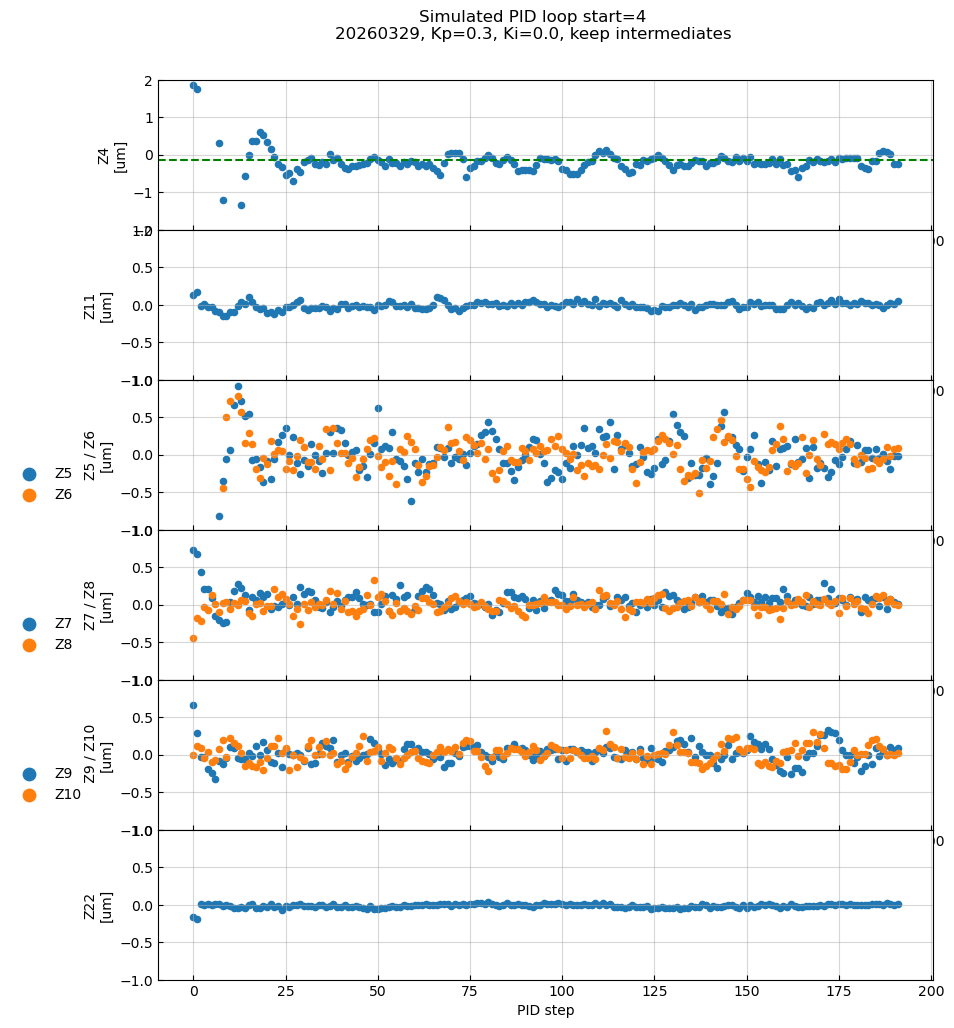

In [129]:
plot_PID(new_zernikes, f"{day_obs}, Kp=0.3, Ki=0.0, keep intermediates")

## Things still needing attention:
(1) Ki and ISum don't work. \
(2) Need to plot original Zernikes vs PID with OLR. \
(3) Not sure if control_vmodes is working \
(4) Zernikes in arcsec and microns aren't right yet. - DONE\
(5) Allow interleaving - DONE \
(6) Extract rot and filter - DONE

In [99]:
ofc.controller.